In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
import warnings
import os
import copy
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
SEED = 42

# ── Thư mục lưu biểu đồ ──────────────────────────────────────────────────────
FIG_ROOT    = '../figures/05_regularization'
###FIG_ROOT    = '../figures_test/05_regularization'

FIG_METRICS = f'{FIG_ROOT}/metrics'      # so sánh R², RMSE, heatmap overfit
FIG_ALPHA   = f'{FIG_ROOT}/alpha'        # phân tích regularization strength
FIG_RESID   = f'{FIG_ROOT}/residuals'    # phân tích phần dư
for _d in [FIG_METRICS, FIG_ALPHA, FIG_RESID]:
    os.makedirs(_d, exist_ok=True)
print('Figure folders ready:', FIG_ROOT)

Figure folders ready: ../figures/05_regularization


## 1. Hàm tiện ích

In [2]:
def load_data(split_folder, data_type='Original'):
    """
    data_type: 'Original' | 'PCA' | 'SVD'
    Trả về None nếu file không tồn tại.
    """
    split = split_folder.split('_')[1] + '_' + split_folder.split('_')[2]

    if data_type == 'Original':
        base_path = f'../processed_data/{split_folder}'
        ###base_path = f'../processed_data_test/{split_folder}'
        x_train_path = f'{base_path}/X_train.csv'
        x_val_path   = f'{base_path}/X_val.csv'
    elif data_type == 'PCA':
        base_path = f'../processed_data/pca_var90_{split}'
        ###base_path = f'../processed_data_test/pca_var90_{split}'
        x_train_path = f'{base_path}/X_train_pca.csv'
        x_val_path   = f'{base_path}/X_val_pca.csv'
    elif data_type == 'SVD':
        base_path = f'../processed_data/svd_{split}'
        ###base_path = f'../processed_data_test/svd_{split}'
        x_train_path = f'{base_path}/X_train_svd.csv'
        x_val_path   = f'{base_path}/X_val_svd.csv'
    else:
        raise ValueError(f'data_type không hợp lệ: {data_type}')

    if not os.path.exists(x_train_path) or not os.path.exists(x_val_path):
        print(f'  [SKIP] Không tìm thấy file dữ liệu: {base_path}')
        return None

    X_train = pd.read_csv(x_train_path)
    X_val   = pd.read_csv(x_val_path)
    y_train = pd.read_csv(f'../processed_data/{split_folder}/y_train.csv')
    y_val   = pd.read_csv(f'../processed_data/{split_folder}/y_val.csv')
    ###y_train = pd.read_csv(f'../processed_data_test/{split_folder}/y_train.csv')
    ###y_val   = pd.read_csv(f'../processed_data_test/{split_folder}/y_val.csv')

    return X_train, X_val, y_train.values.ravel(), y_val.values.ravel()

In [3]:
def get_metrics(y_true, y_pred, n_features):
    n = len(y_true)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return dict(MSE=round(mse,4), RMSE=round(rmse,4), MAE=round(mae,4),
                R2=round(r2,6), Adj_R2=round(adj_r2,6), MAPE=round(mape,4))

In [4]:
def evaluate_model(model, X_train, X_val, y_train, y_val):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_val_pred   = model.predict(X_val)
    n_feat = X_train.shape[1]
    tr_m = get_metrics(y_train, y_train_pred, n_feat)
    vl_m = get_metrics(y_val,   y_val_pred,   n_feat)
    residuals = y_val - y_val_pred
    return tr_m, vl_m, y_val_pred, residuals

## 2. Thực nghiệm 

In [5]:
splits = ['split_80_20', 'split_70_30', 'split_60_40']
split_labels = {'split_80_20': '80/20', 'split_70_30': '70/30', 'split_60_40': '60/40'}
data_types = ['Original', 'PCA', 'SVD']

model_configs = [
    ('Linear', LinearRegression()),
    ('Ridge',  Ridge(alpha=1.0)),
    ('Lasso',  Lasso(alpha=0.01, max_iter=5000)),
]
model_list = [m[0] for m in model_configs]

results = []
residuals_store = {}   # key: (model_name, data_type)

for split in splits:
    print(f'\n=== {split_labels[split]} ===')
    for dt in data_types:
        loaded = load_data(split, data_type=dt)
        if loaded is None:
            continue
        X_train, X_val, y_train, y_val = loaded
        for model_name, model in model_configs:
            m = copy.deepcopy(model)
            tr_m, vl_m, y_pred, resid = evaluate_model(m, X_train, X_val, y_train, y_val)
            row = {
                'Model': model_name, 'Data': dt,
                'Split': split_labels[split],
                'Train_R2': tr_m['R2'], 'Val_R2': vl_m['R2'],
                'Delta_R2': round(tr_m['R2'] - vl_m['R2'], 6),
                'Train_RMSE': tr_m['RMSE'], 'Val_RMSE': vl_m['RMSE'],
                'Train_MAE': tr_m['MAE'],   'Val_MAE':  vl_m['MAE'],
                'Val_MAPE': vl_m['MAPE'],   'Val_Adj_R2': vl_m['Adj_R2'],
            }
            results.append(row)
            if split == 'split_80_20':
                residuals_store[(model_name, dt)] = {
                    'residuals': resid, 'y_pred': y_pred, 'y_val': y_val,
                    'X_val': X_val
                }
            print(f'  {model_name:8s} | {dt:8s} | '
                  f'Train R²={tr_m["R2"]:.4f}  Val R²={vl_m["R2"]:.4f}  '
                  f'ΔR²={tr_m["R2"]-vl_m["R2"]:+.4f}  RMSE={vl_m["RMSE"]:.4f}')

results_df = pd.DataFrame(results)


=== 80/20 ===
  Linear   | Original | Train R²=0.6109  Val R²=0.6067  ΔR²=+0.0043  RMSE=4.8551
  Ridge    | Original | Train R²=0.6109  Val R²=0.6067  ΔR²=+0.0043  RMSE=4.8551
  Lasso    | Original | Train R²=0.6108  Val R²=0.6069  ΔR²=+0.0039  RMSE=4.8533
  [SKIP] Không tìm thấy file dữ liệu: ../processed_data/pca_var90_80_20
  [SKIP] Không tìm thấy file dữ liệu: ../processed_data/svd_80_20

=== 70/30 ===
  Linear   | Original | Train R²=0.6103  Val R²=0.6095  ΔR²=+0.0008  RMSE=4.8411
  Ridge    | Original | Train R²=0.6103  Val R²=0.6095  ΔR²=+0.0008  RMSE=4.8411
  Lasso    | Original | Train R²=0.6102  Val R²=0.6097  ΔR²=+0.0005  RMSE=4.8402
  [SKIP] Không tìm thấy file dữ liệu: ../processed_data/pca_var90_70_30
  [SKIP] Không tìm thấy file dữ liệu: ../processed_data/svd_70_30

=== 60/40 ===
  Linear   | Original | Train R²=0.6104  Val R²=0.6094  ΔR²=+0.0010  RMSE=4.8480
  Ridge    | Original | Train R²=0.6104  Val R²=0.6094  ΔR²=+0.0010  RMSE=4.8480
  Lasso    | Original | Train R

In [6]:
print("=== Bảng tổng hợp kết quả ===")
display_cols = ['Model','Data','Split',
                'Train_R2','Val_R2','Delta_R2',
                'Val_RMSE','Val_MAE','Val_MAPE','Val_Adj_R2']
results_df[display_cols].sort_values(['Data','Split','Model'])

=== Bảng tổng hợp kết quả ===


,Model,Data,Split,Train_R2,Val_R2,Delta_R2,Val_RMSE,Val_MAE,Val_MAPE,Val_Adj_R2
8,Lasso,Original,60/40,0.610237,0.609600,0.000637,4.8470,3.8797,21.2543,0.609039
6,Linear,Original,60/40,0.610398,0.609434,0.000964,4.8480,3.8808,21.2148,0.608874
7,Ridge,Original,60/40,0.610398,0.609433,0.000965,4.8480,3.8808,21.2151,0.608872
5,Lasso,Original,70/30,0.610157,0.609657,0.000500,4.8402,3.8773,19.4896,0.608909
3,Linear,Original,70/30,0.610303,0.609510,0.000793,4.8411,3.8781,19.4732,0.608762
4,Ridge,Original,70/30,0.610303,0.609508,0.000795,4.8411,3.8781,19.4733,0.608760
2,Lasso,Original,80/20,0.610808,0.606950,0.003858,4.8533,3.8825,19.4833,0.605820
0,Linear,Original,80/20,0.610948,0.606654,0.004294,4.8551,3.8842,19.4692,0.605523
1,Ridge,Original,80/20,0.610947,0.606653,0.004294,4.8551,3.8842,19.4695,0.605522


## 3. Biểu đồ so sánh R² và RMSE – 3 mô hình

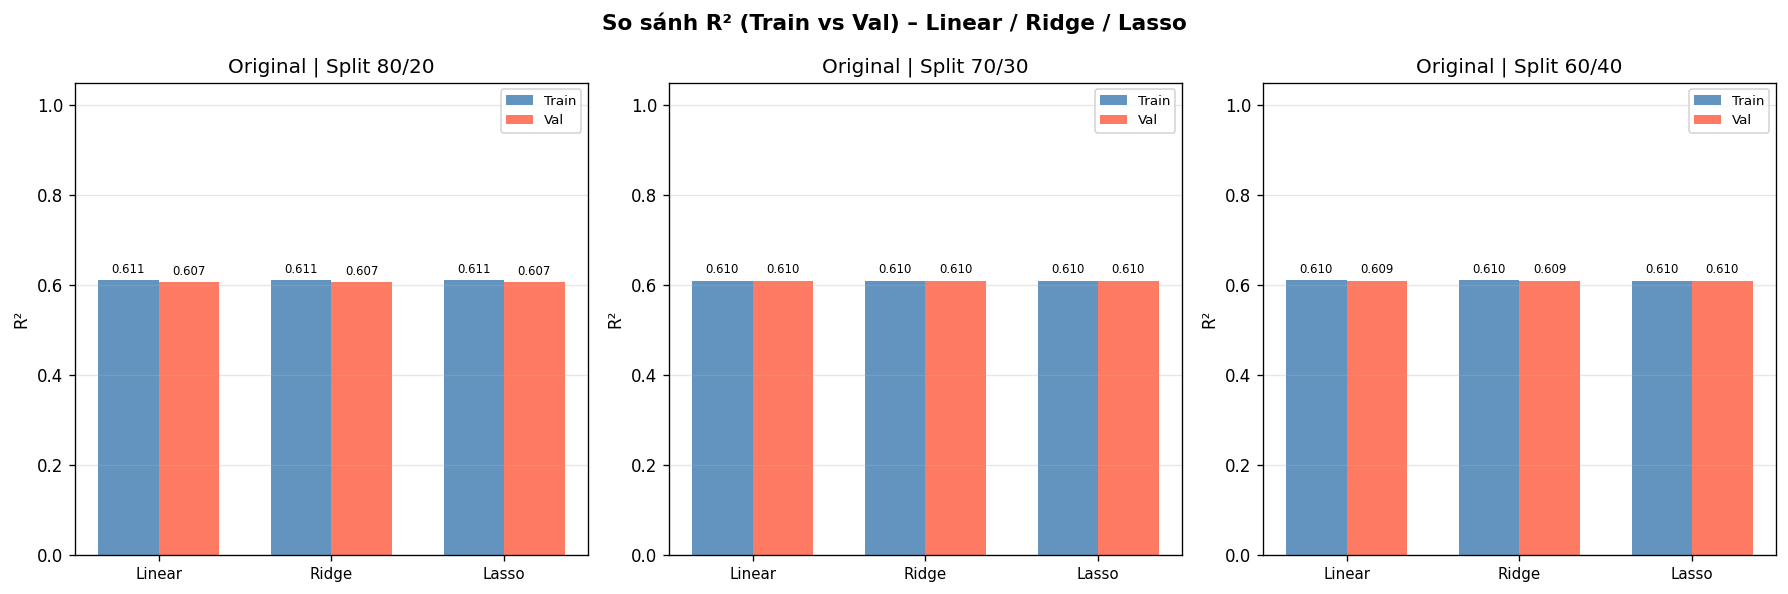

In [7]:
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
fig, axes = plt.subplots(len(avail_dt), 3, figsize=(15, 5*len(avail_dt)))
if len(avail_dt) == 1: axes = axes.reshape(1, -1)
fig.suptitle('So sánh R² (Train vs Val) – Linear / Ridge / Lasso',
             fontsize=13, fontweight='bold')

avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
for row_i, data_type in enumerate(avail_dt):
    for col_j, split_label in enumerate(['80/20', '70/30', '60/40']):
        ax = axes[row_i, col_j]
        sub = results_df[(results_df['Data'] == data_type) &
                         (results_df['Split'] == split_label)]
        x = np.arange(len(sub))
        w = 0.35
        bars1 = ax.bar(x - w/2, sub['Train_R2'], w, label='Train', color='steelblue', alpha=0.85)
        bars2 = ax.bar(x + w/2, sub['Val_R2'],   w, label='Val',   color='tomato',    alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(sub['Model'].values, fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('R²')
        ax.set_title(f'{data_type} | Split {split_label}')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        for bar in [*bars1, *bars2]:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIG_METRICS}/r2_comparison.png', bbox_inches='tight')
plt.show()

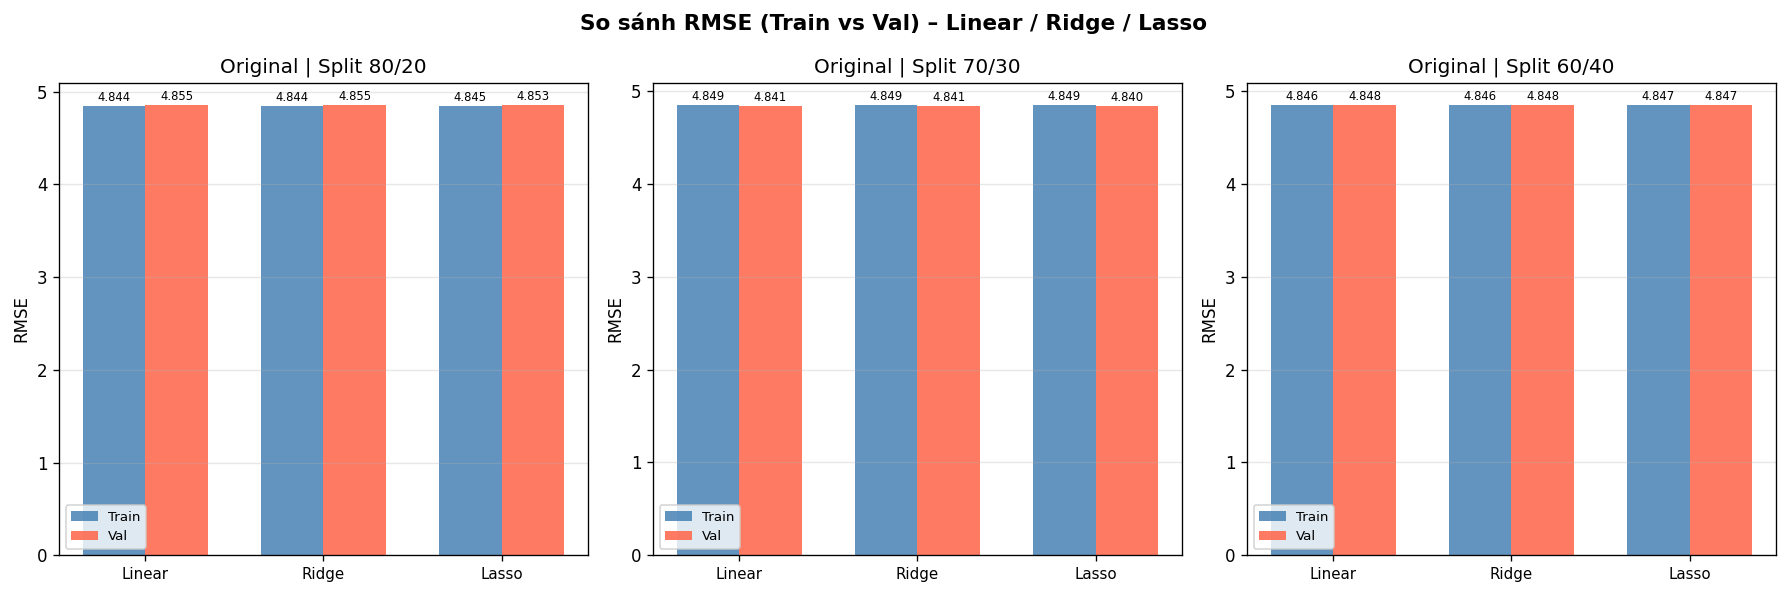

In [8]:
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
fig, axes = plt.subplots(len(avail_dt), 3, figsize=(15, 5*len(avail_dt)))
if len(avail_dt) == 1: axes = axes.reshape(1, -1)
fig.suptitle('So sánh RMSE (Train vs Val) – Linear / Ridge / Lasso',
             fontsize=13, fontweight='bold')

avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
for row_i, data_type in enumerate(avail_dt):
    for col_j, split_label in enumerate(['80/20', '70/30', '60/40']):
        ax = axes[row_i, col_j]
        sub = results_df[(results_df['Data'] == data_type) &
                         (results_df['Split'] == split_label)]
        x = np.arange(len(sub))
        w = 0.35
        bars1 = ax.bar(x - w/2, sub['Train_RMSE'], w, label='Train', color='steelblue', alpha=0.85)
        bars2 = ax.bar(x + w/2, sub['Val_RMSE'],   w, label='Val',   color='tomato',    alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(sub['Model'].values, fontsize=9)
        ax.set_ylabel('RMSE')
        ax.set_title(f'{data_type} | Split {split_label}')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        for bar in [*bars1, *bars2]:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIG_METRICS}/rmse_comparison.png', bbox_inches='tight')
plt.show()

## 4. Phân tích Overfit – Heatmap ΔR²

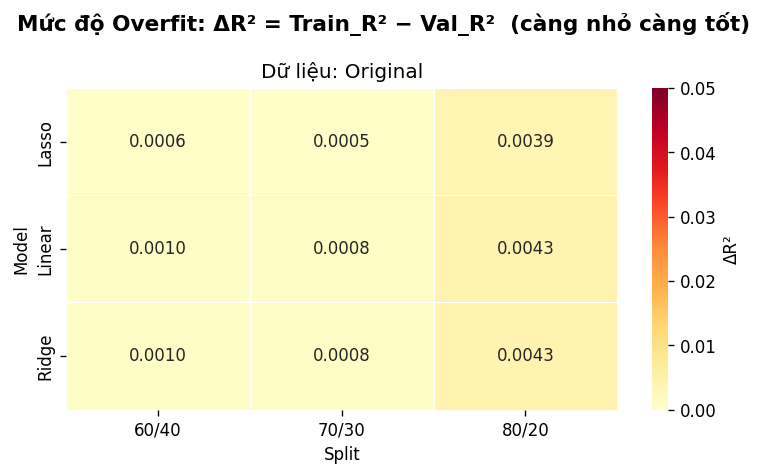

In [9]:
avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
fig, axes = plt.subplots(1, len(avail_dt), figsize=(6.5*len(avail_dt), 4))
if len(avail_dt) == 1: axes = [axes]
fig.suptitle('Mức độ Overfit: ΔR² = Train_R² − Val_R²  (càng nhỏ càng tốt)',
             fontsize=13, fontweight='bold')

avail_dt = [dt for dt in data_types if dt in results_df['Data'].unique()]
for ax, data_type in zip(axes, avail_dt):
    sub = results_df[results_df['Data'] == data_type]
    pivot = sub.pivot_table(index='Model', columns='Split', values='Delta_R2')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                linewidths=0.5, cbar_kws={'label': 'ΔR²'}, ax=ax,
                vmin=0, vmax=0.05)
    ax.set_title(f'Dữ liệu: {data_type}')

plt.tight_layout()
plt.savefig(f'{FIG_METRICS}/overfit_heatmap.png', bbox_inches='tight')
plt.show()

## 5. So sánh PCA vs SVD – hai phương pháp giảm chiều

In [10]:
# Chỉ chạy nếu cả PCA và SVD đều có dữ liệu
avail = results_df['Data'].unique()
dim_methods = [dt for dt in ['PCA', 'SVD'] if dt in avail]

if len(dim_methods) < 2:
    print('Chưa đủ dữ liệu để so sánh PCA và SVD (cần cả hai).')
else:
    split_order = ['80/20', '70/30', '60/40']
    colors_model = {'Linear': 'steelblue', 'Ridge': 'darkorange', 'Lasso': 'mediumseagreen'}

    # Bảng tóm tắt split 80/20
    print('=== So sánh Val R² – PCA vs SVD (split 80/20) ===')
    sub = results_df[results_df['Split'] == '80/20']
    pivot_r2 = sub.pivot_table(index='Model', columns='Data', values='Val_R2')
    print(pivot_r2.to_string())

    # Biểu đồ Val R²: grouped by Model, x=Data type (Original/PCA/SVD)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('So sánh Val R²: Original vs PCA vs SVD theo từng mô hình',
                 fontsize=12, fontweight='bold')

    for ax, split_label in zip(axes, split_order):
        sub = results_df[results_df['Split'] == split_label]
        x = np.arange(len(dim_methods) + 1)  # Original + dim_methods
        w = 0.25
        dt_order = ['Original'] + dim_methods
        for i, mname in enumerate(model_list):
            vals = []
            for dt in dt_order:
                row = sub[(sub['Model'] == mname) & (sub['Data'] == dt)]
                vals.append(row['Val_R2'].values[0] if len(row) > 0 else np.nan)
            bars = ax.bar(x + i*w, vals, w, label=mname,
                          color=colors_model.get(mname, 'gray'), alpha=0.85)
            for bar in bars:
                if not np.isnan(bar.get_height()):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
        ax.set_xticks(x + w)
        ax.set_xticklabels(dt_order)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Val R²')
        ax.set_title(f'Split {split_label}')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIG_METRICS}/compare_pca_svd_r2.png', bbox_inches='tight')
    plt.show()

    # Biểu đồ Delta R² (overfit): PCA vs SVD
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('So sánh ΔR² (overfit): Original vs PCA vs SVD theo từng mô hình',
                 fontsize=12, fontweight='bold')

    for ax, split_label in zip(axes, split_order):
        sub = results_df[results_df['Split'] == split_label]
        x = np.arange(len(dim_methods) + 1)
        w = 0.25
        dt_order = ['Original'] + dim_methods
        for i, mname in enumerate(model_list):
            vals = []
            for dt in dt_order:
                row = sub[(sub['Model'] == mname) & (sub['Data'] == dt)]
                vals.append(row['Delta_R2'].values[0] if len(row) > 0 else np.nan)
            ax.bar(x + i*w, vals, w, label=mname,
                   color=colors_model.get(mname, 'gray'), alpha=0.85)
        ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='Ngưỡng 0.05')
        ax.set_xticks(x + w)
        ax.set_xticklabels(dt_order)
        ax.set_ylabel('ΔR²')
        ax.set_title(f'Split {split_label}')
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIG_METRICS}/compare_pca_svd_delta_r2.png', bbox_inches='tight')
    plt.show()

    # Nhận xét tóm tắt
    print('\n=== Mức giảm Val R² so với Original (split 80/20, model Linear) ===')
    orig_r2 = results_df[(results_df['Data']=='Original') & (results_df['Split']=='80/20')
                         & (results_df['Model']=='Linear')]['Val_R2'].values[0]
    for dt in dim_methods:
        row = results_df[(results_df['Data']==dt) & (results_df['Split']=='80/20')
                         & (results_df['Model']=='Linear')]
        if len(row) == 0: continue
        delta = orig_r2 - row['Val_R2'].values[0]
        n_comp = row['Val_R2'].shape[0]
        print(f'  {dt}: Val R²={row["Val_R2"].values[0]:.4f}  ΔR²={delta:+.4f}')


Chưa đủ dữ liệu để so sánh PCA và SVD (cần cả hai).


## 5. Phân tích Regularization – Ảnh hưởng của α
### 5.1 Ridge

In [11]:
X_train, X_val, y_train, y_val = load_data('split_80_20')

alphas_ridge = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10, 50, 100, 500, 1000]
alphas_lasso = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

ridge_rows, lasso_rows = [], []

for alpha in alphas_ridge:
    tr_m, vl_m, _, _ = evaluate_model(Ridge(alpha=alpha), X_train, X_val, y_train, y_val)
    ridge_rows.append({'alpha': alpha, 'Train_R2': tr_m['R2'], 'Val_R2': vl_m['R2'],
                       'Train_RMSE': tr_m['RMSE'], 'Val_RMSE': vl_m['RMSE'],
                       'Delta_R2': tr_m['R2'] - vl_m['R2']})

for alpha in alphas_lasso:
    tr_m, vl_m, _, _ = evaluate_model(Lasso(alpha=alpha, max_iter=5000),
                                       X_train, X_val, y_train, y_val)
    lasso_rows.append({'alpha': alpha, 'Train_R2': tr_m['R2'], 'Val_R2': vl_m['R2'],
                       'Train_RMSE': tr_m['RMSE'], 'Val_RMSE': vl_m['RMSE'],
                       'Delta_R2': tr_m['R2'] - vl_m['R2']})

ridge_df = pd.DataFrame(ridge_rows)
lasso_df = pd.DataFrame(lasso_rows)

print("Ridge – R² theo alpha:")
print(ridge_df[['alpha','Train_R2','Val_R2','Delta_R2','Val_RMSE']].to_string(index=False))
print("\nLasso – R² theo alpha:")
print(lasso_df[['alpha','Train_R2','Val_R2','Delta_R2','Val_RMSE']].to_string(index=False))

Ridge – R² theo alpha:
   alpha  Train_R2   Val_R2  Delta_R2  Val_RMSE
   0.001  0.610948 0.606654  0.004294    4.8551
   0.010  0.610948 0.606654  0.004294    4.8551
   0.100  0.610948 0.606654  0.004294    4.8551
   0.500  0.610947 0.606653  0.004294    4.8551
   1.000  0.610947 0.606653  0.004294    4.8551
   5.000  0.610946 0.606652  0.004294    4.8551
  10.000  0.610946 0.606652  0.004294    4.8551
  50.000  0.610946 0.606653  0.004293    4.8551
 100.000  0.610946 0.606654  0.004292    4.8551
 500.000  0.610935 0.606655  0.004280    4.8551
1000.000  0.610903 0.606637  0.004266    4.8552

Lasso – R² theo alpha:
 alpha  Train_R2   Val_R2  Delta_R2  Val_RMSE
0.0001  0.610945 0.606657  0.004288    4.8551
0.0010  0.610942 0.606704  0.004238    4.8548
0.0050  0.610888 0.606836  0.004052    4.8540
0.0100  0.610808 0.606950  0.003858    4.8533
0.0500  0.610126 0.606644  0.003482    4.8552
0.1000  0.609372 0.606016  0.003356    4.8591
0.5000  0.600530 0.597783  0.002747    4.9096
1.0000  0

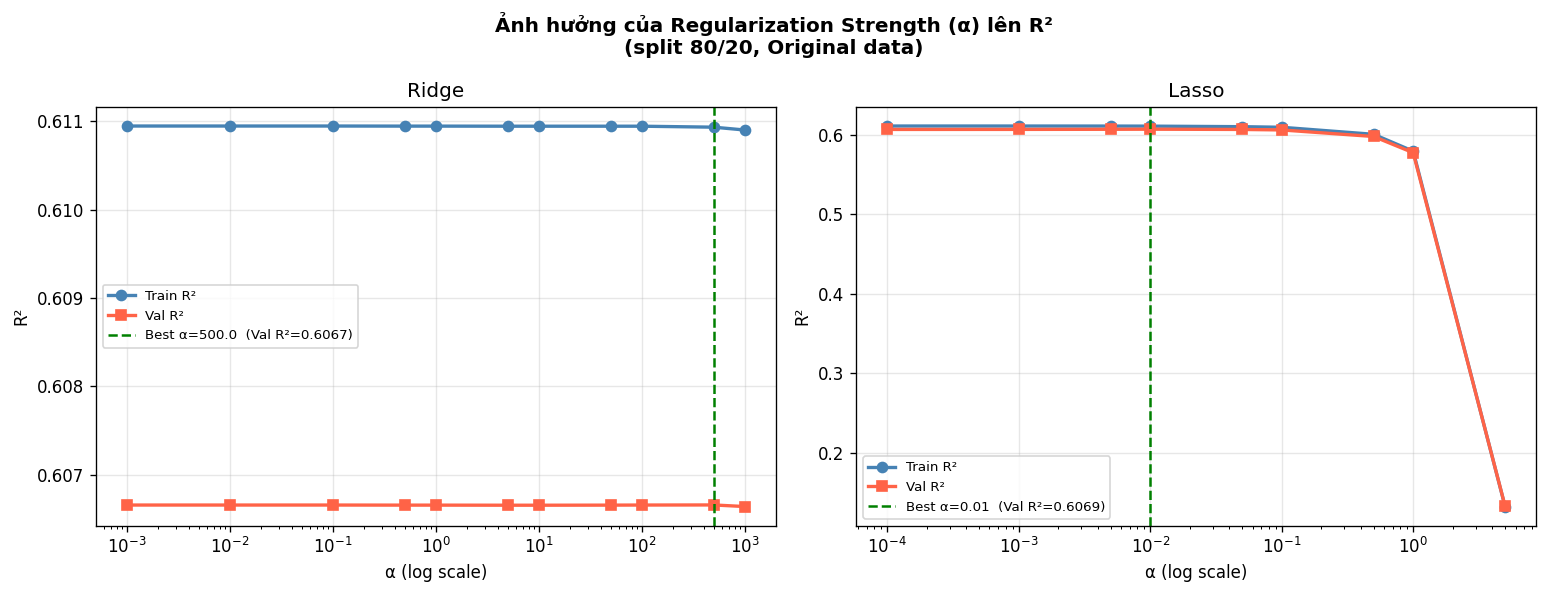

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ảnh hưởng của Regularization Strength (α) lên R²\n(split 80/20, Original data)',
             fontsize=12, fontweight='bold')

for ax, df, title in zip(axes, [ridge_df, lasso_df], ['Ridge', 'Lasso']):
    ax.semilogx(df['alpha'], df['Train_R2'], 'o-', color='steelblue',
                label='Train R²', linewidth=2)
    ax.semilogx(df['alpha'], df['Val_R2'],   's-', color='tomato',
                label='Val R²',   linewidth=2)
    best_idx   = df['Val_R2'].idxmax()
    best_alpha = df.loc[best_idx, 'alpha']
    best_r2    = df.loc[best_idx, 'Val_R2']
    ax.axvline(best_alpha, color='green', linestyle='--', linewidth=1.5,
               label=f'Best α={best_alpha}  (Val R²={best_r2:.4f})')
    ax.set_xlabel('α (log scale)')
    ax.set_ylabel('R²')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_ALPHA}/ridge_lasso_alpha_r2.png', bbox_inches='tight')
plt.show()

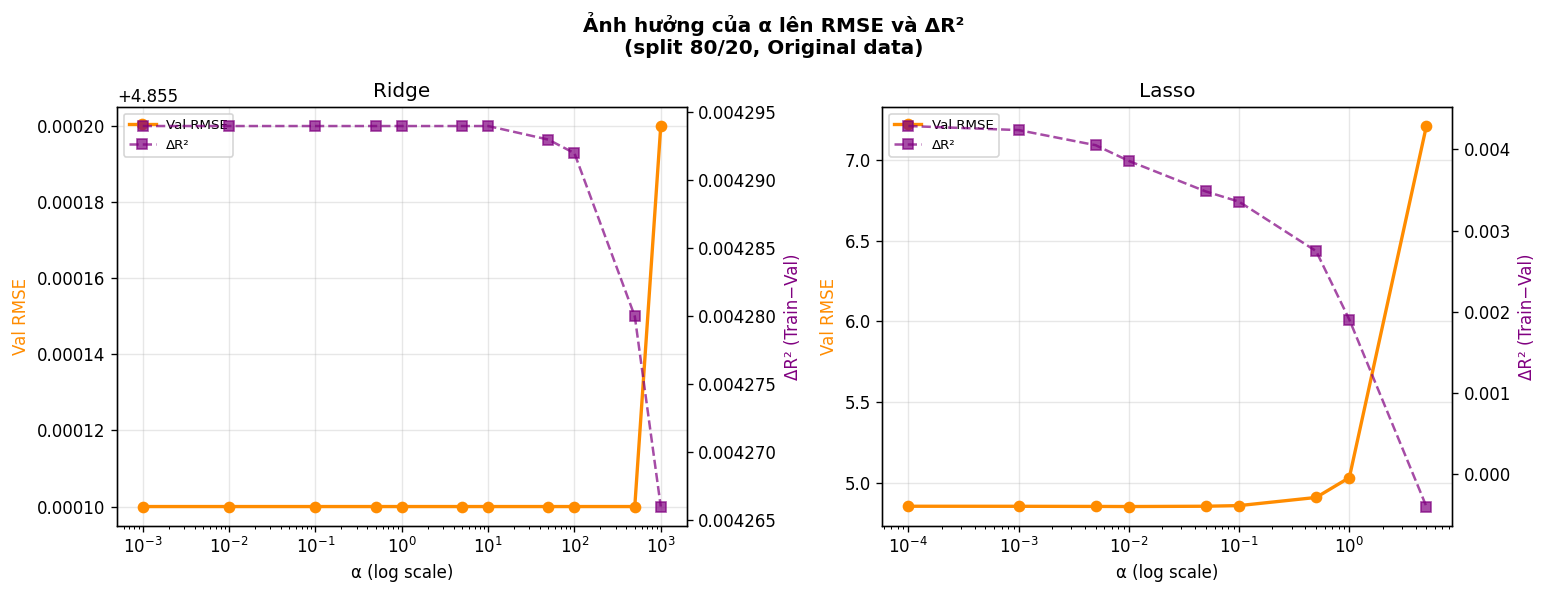

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Ảnh hưởng của α lên RMSE và ΔR²\n(split 80/20, Original data)',
             fontsize=12, fontweight='bold')

for ax, df, title in zip(axes, [ridge_df, lasso_df], ['Ridge', 'Lasso']):
    ax2 = ax.twinx()
    ax.semilogx(df['alpha'], df['Val_RMSE'], 'o-', color='darkorange',
                label='Val RMSE', linewidth=2)
    ax2.semilogx(df['alpha'], df['Delta_R2'], 's--', color='purple',
                 label='ΔR²', linewidth=1.5, alpha=0.7)
    ax.set_xlabel('α (log scale)')
    ax.set_ylabel('Val RMSE', color='darkorange')
    ax2.set_ylabel('ΔR² (Train−Val)', color='purple')
    ax.set_title(title)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_ALPHA}/ridge_lasso_alpha_rmse_delta.png', bbox_inches='tight')
plt.show()

### 5.2 Lasso – Hệ số hồi quy theo α (regularization path)

Features với hệ số ≠ 0: 41 / 86
Features bị zeroed out: 45


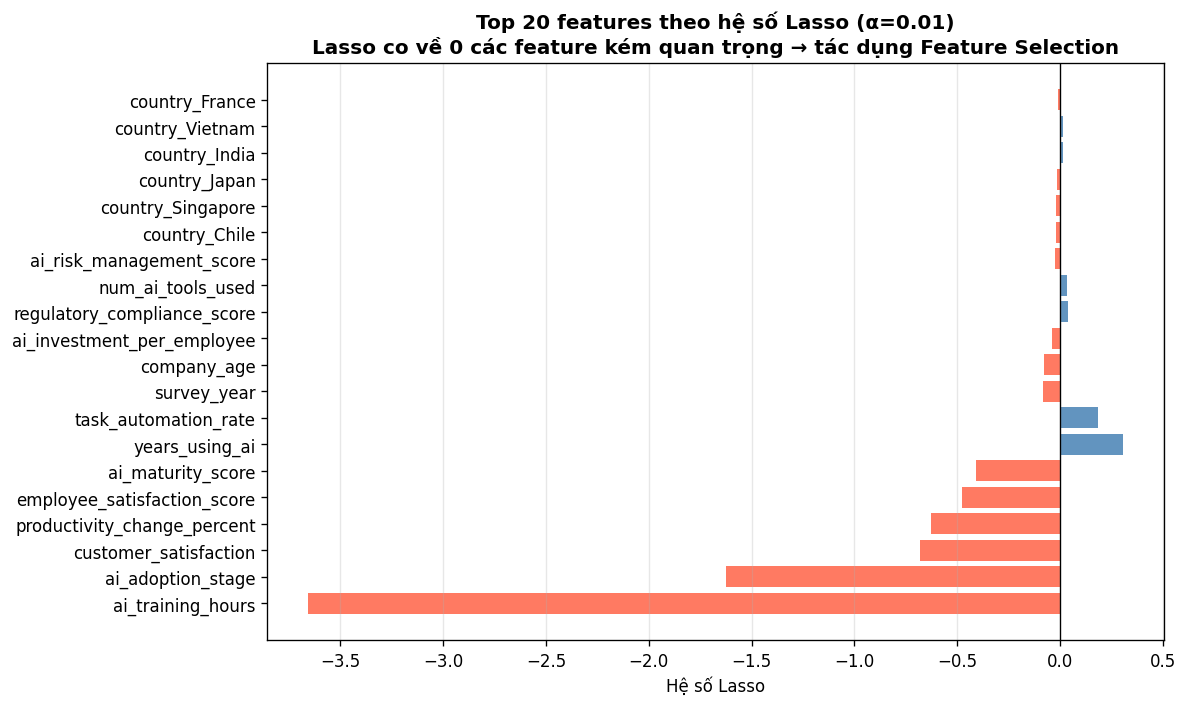

In [14]:
X_train, X_val, y_train, y_val = load_data('split_80_20')

lasso_best = Lasso(alpha=0.01, max_iter=5000)
lasso_best.fit(X_train, y_train)

coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lasso_best.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
nonzero = (coef_df['Coefficient'] != 0).sum()
zeroed  = (coef_df['Coefficient'] == 0).sum()

print(f"Features với hệ số ≠ 0: {nonzero} / {len(coef_df)}")
print(f"Features bị zeroed out: {zeroed}")

top20 = coef_df.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['tomato' if c < 0 else 'steelblue' for c in top20['Coefficient']]
ax.barh(top20['Feature'], top20['Coefficient'], color=colors_bar, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Hệ số Lasso')
ax.set_title('Top 20 features theo hệ số Lasso (α=0.01)\n'
             'Lasso co về 0 các feature kém quan trọng → tác dụng Feature Selection',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_ALPHA}/lasso_coefficients.png', bbox_inches='tight')
plt.show()

## 6. Phân tích phần dư (Residual Analysis) – 1.4(b)
### 6.1 Residual plots cơ bản cho 3 mô hình (split 80/20, Original)

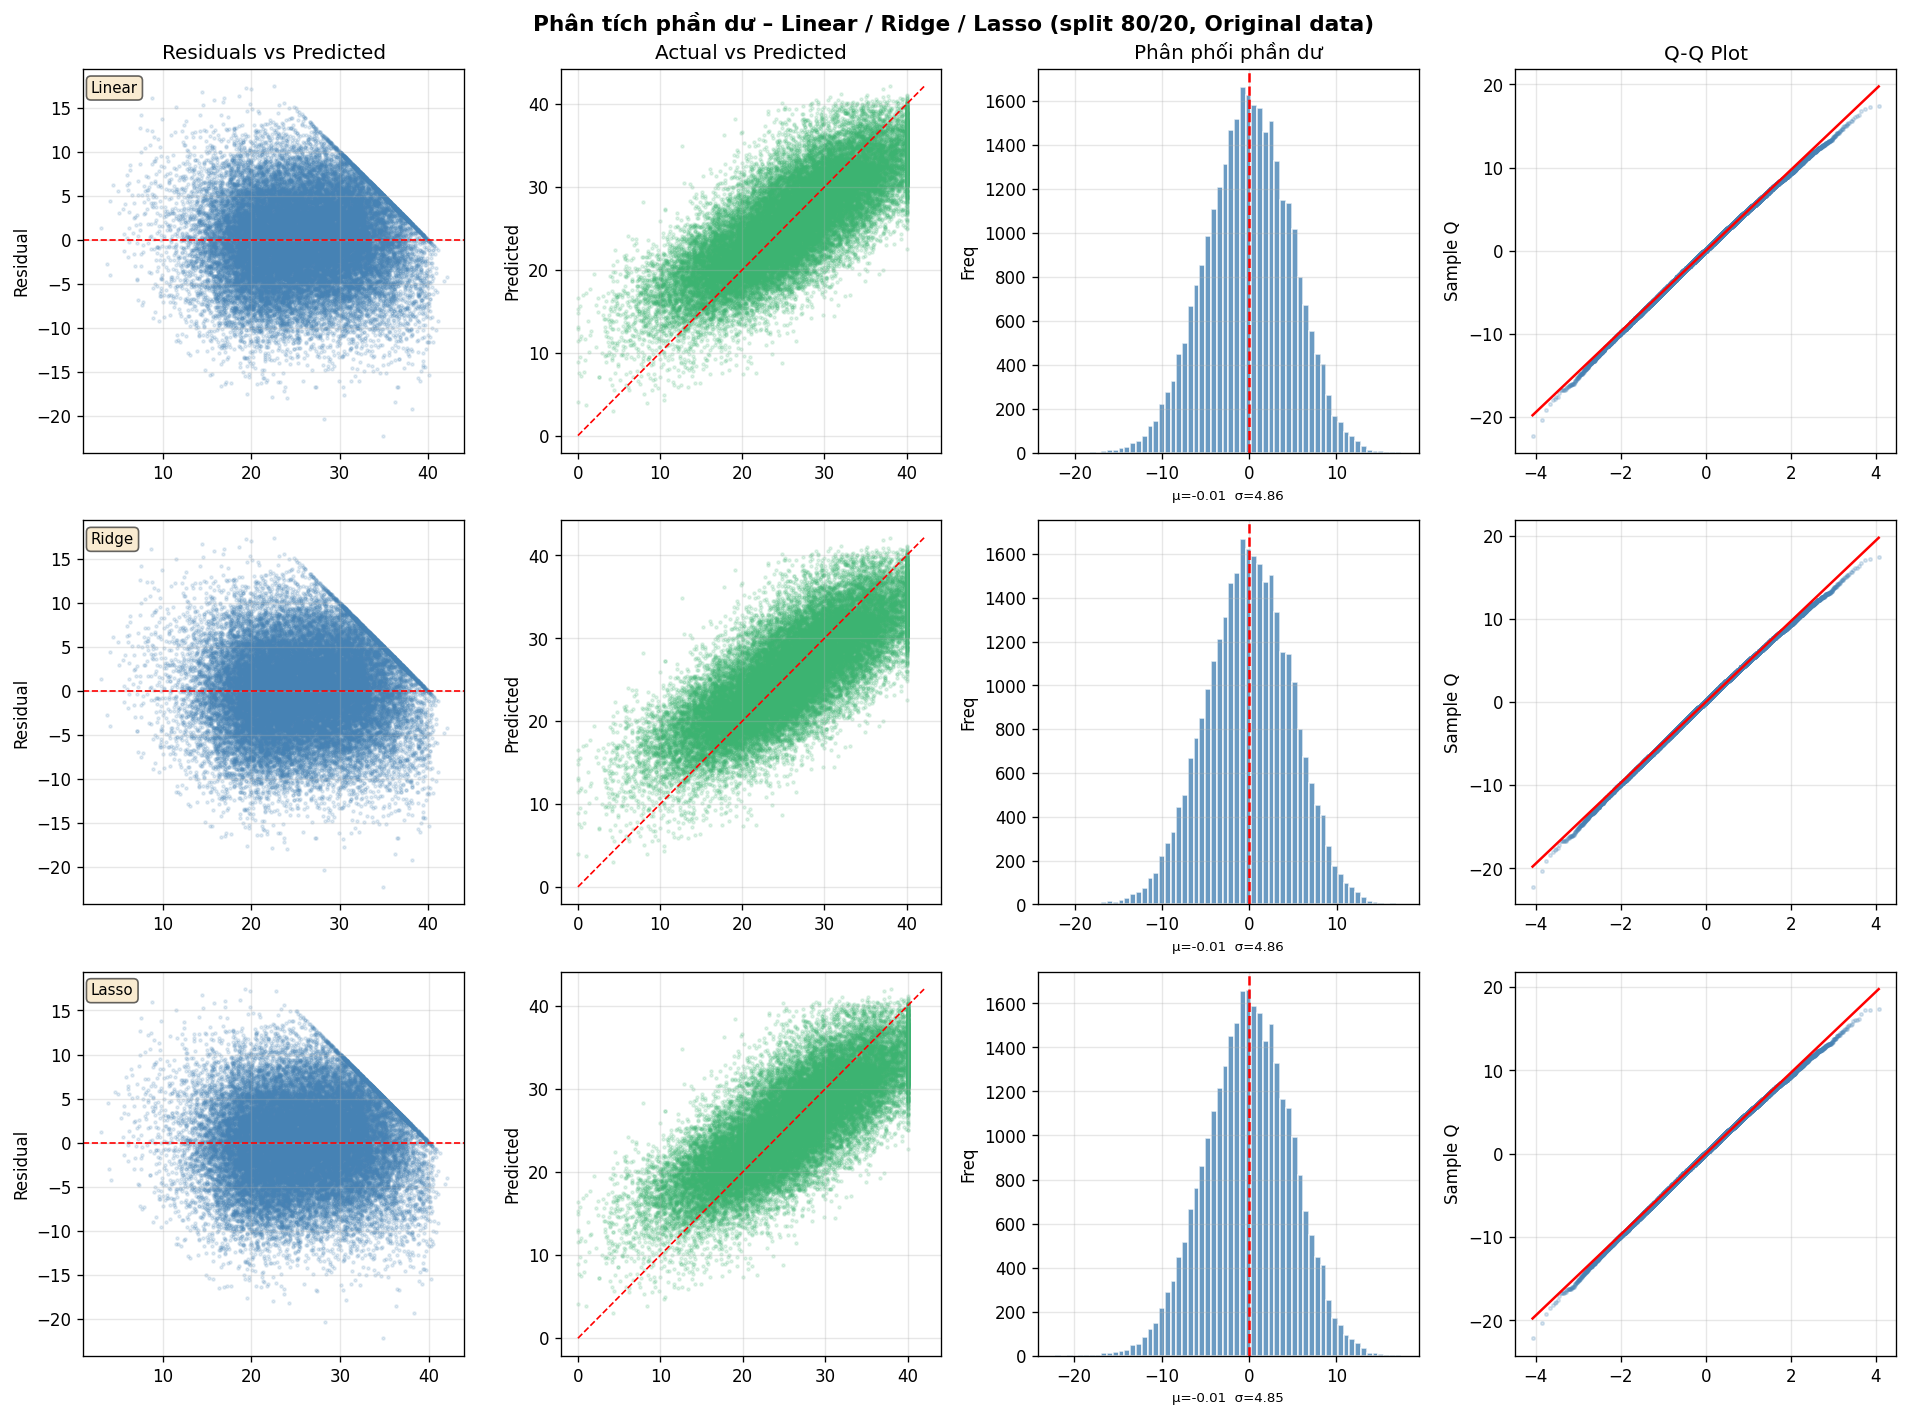

In [15]:
model_list = ['Linear', 'Ridge', 'Lasso']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Phân tích phần dư – Linear / Ridge / Lasso (split 80/20, Original data)',
             fontsize=13, fontweight='bold')

col_titles = ['Residuals vs Predicted', 'Actual vs Predicted',
              'Phân phối phần dư', 'Q-Q Plot']
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t)

for row_i, mname in enumerate(model_list):
    store  = residuals_store[(mname, 'Original')]
    resid  = store['residuals']
    y_pred = store['y_pred']
    y_val  = store['y_val']

    # Col 0: Residuals vs Predicted
    ax = axes[row_i, 0]
    ax.scatter(y_pred, resid, alpha=0.15, s=3, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('Residual')
    ax.text(0.02, 0.97, mname, transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))
    ax.grid(alpha=0.3)

    # Col 1: Actual vs Predicted
    ax = axes[row_i, 1]
    ax.scatter(y_val, y_pred, alpha=0.15, s=3, color='mediumseagreen')
    lims = [min(y_val.min(), y_pred.min()), max(y_val.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_ylabel('Predicted')
    ax.grid(alpha=0.3)

    # Col 2: Histogram
    ax = axes[row_i, 2]
    ax.hist(resid, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_ylabel('Freq')
    ax.set_xlabel(f'μ={resid.mean():.2f}  σ={resid.std():.2f}', fontsize=8)
    ax.grid(alpha=0.3)

    # Col 3: Q-Q plot
    ax = axes[row_i, 3]
    (osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
    ax.plot(osm, osr, 'o', alpha=0.2, markersize=2, color='steelblue')
    ax.plot(osm, slope*np.array(osm)+intercept, 'r-', linewidth=1.5)
    ax.set_ylabel('Sample Q')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_RESID}/residual_all_models.png', bbox_inches='tight')
plt.show()

### 6.2 Tương quan phần dư vs features – Linear và Lasso (Original)

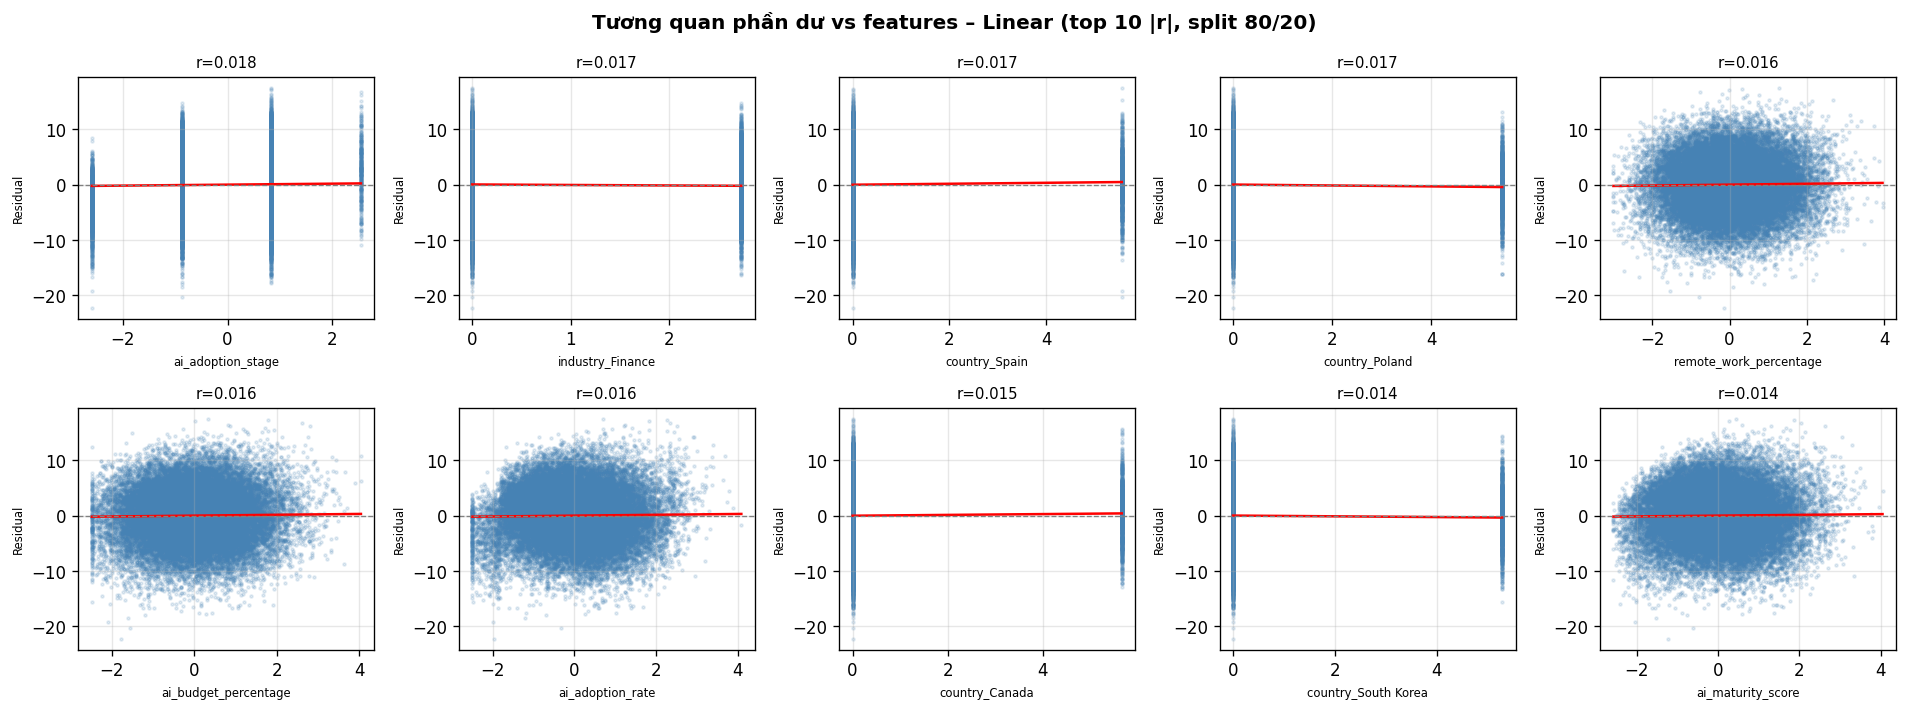


[Linear] Top 10 |r| residual–feature:
ai_adoption_stage         0.018225
industry_Finance          0.017296
country_Spain             0.017206
country_Poland            0.016827
remote_work_percentage    0.016253
ai_budget_percentage      0.015923
ai_adoption_rate          0.015644
country_Canada            0.014951
country_South Korea       0.014104
ai_maturity_score         0.014064


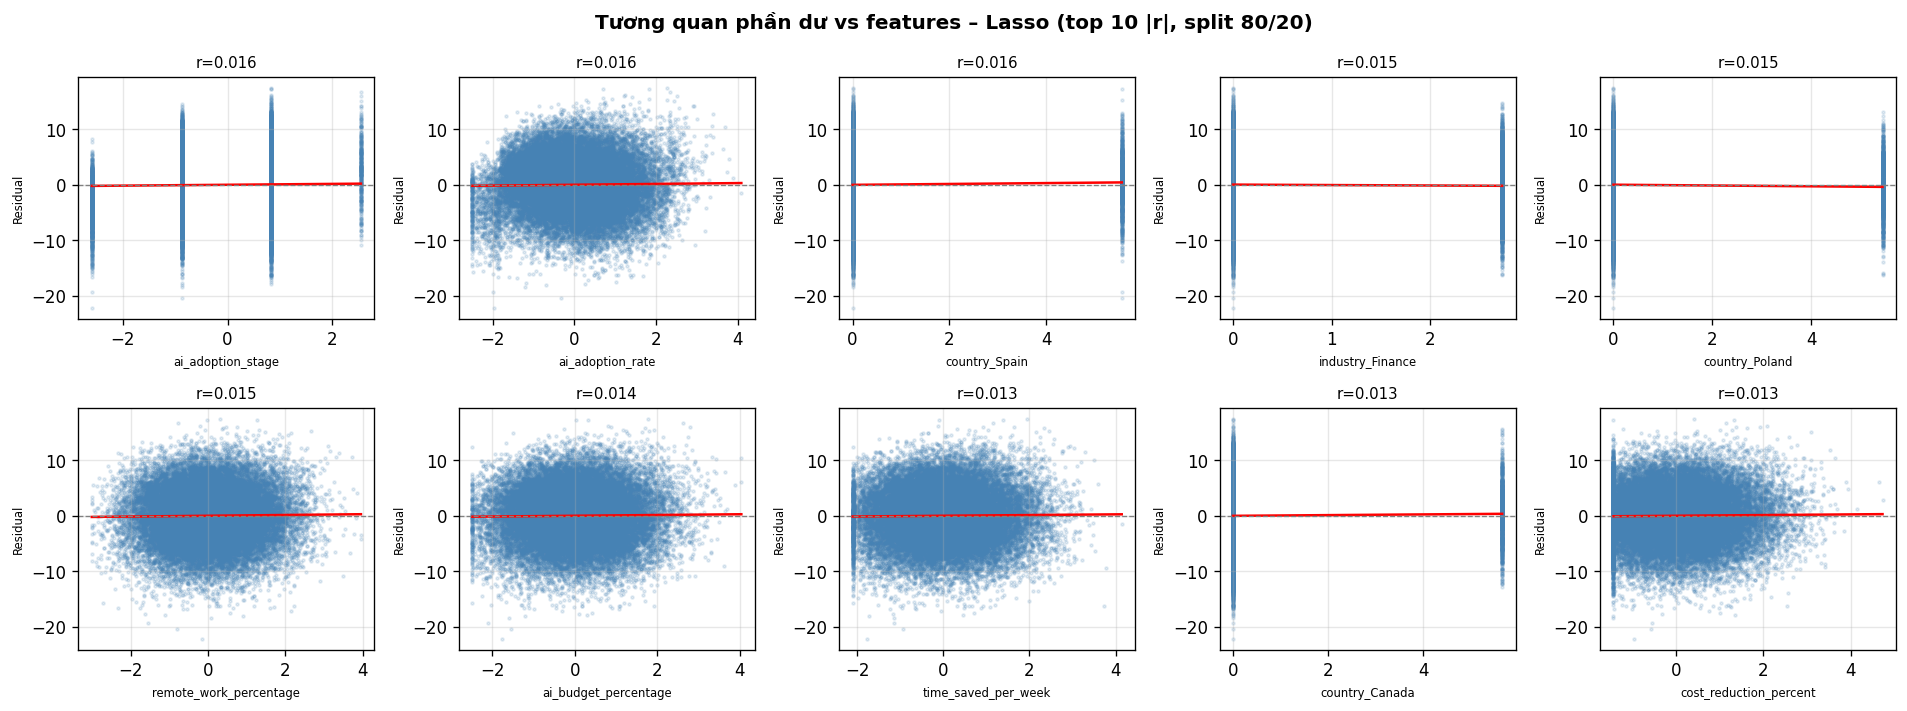


[Lasso] Top 10 |r| residual–feature:
ai_adoption_stage         0.016291
ai_adoption_rate          0.015630
country_Spain             0.015616
industry_Finance          0.015361
country_Poland            0.014713
remote_work_percentage    0.014561
ai_budget_percentage      0.014063
time_saved_per_week       0.013131
country_Canada            0.013004
cost_reduction_percent    0.012855


In [16]:
for mname in ['Linear', 'Lasso']:
    store = residuals_store.get((mname, 'Original'))
    if store is None: continue
    resid = store['residuals']
    X_val = store['X_val']

    corr_resid = X_val.apply(lambda col: np.corrcoef(col, resid)[0, 1])
    top_corr   = corr_resid.abs().nlargest(10)

    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    fig.suptitle(f'Tương quan phần dư vs features – {mname} (top 10 |r|, split 80/20)',
                 fontsize=12, fontweight='bold')
    axes = axes.flatten()

    for i, feat in enumerate(top_corr.index):
        axes[i].scatter(X_val[feat], resid, alpha=0.15, s=3, color='steelblue')
        z  = np.polyfit(X_val[feat], resid, 1)
        xs = np.linspace(X_val[feat].min(), X_val[feat].max(), 100)
        axes[i].plot(xs, np.poly1d(z)(xs), 'r-', linewidth=1.5)
        axes[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axes[i].set_xlabel(feat, fontsize=7)
        axes[i].set_ylabel('Residual', fontsize=7)
        axes[i].set_title(f'r={top_corr[feat]:.3f}', fontsize=9)
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{FIG_RESID}/residual_features_{mname.lower()}.png', bbox_inches='tight')
    plt.show()

    print(f"\n[{mname}] Top 10 |r| residual–feature:")
    print(top_corr.to_string())

### 6.3 Kiểm định thống kê phần dư

In [17]:
from scipy.stats import kstest

for mname in model_list:
    store = residuals_store.get((mname, 'Original'))
    if store is None: continue
    resid = store['residuals']
    print(f"\n{'='*50}")
    print(f"Kiểm định phần dư – {mname} (Original, 80/20)")
    print(f"{'='*50}")
    print(f"  Mean    : {resid.mean():.4f}  (gần 0 → không bias)")
    print(f"  Std     : {resid.std():.4f}")
    print(f"  Skewness: {pd.Series(resid).skew():.4f}")
    print(f"  Kurtosis: {pd.Series(resid).kurtosis():.4f}")
    ks_stat, ks_p = kstest((resid - resid.mean()) / resid.std(), 'norm')
    print(f"  KS test : stat={ks_stat:.4f}, p={ks_p:.4e}",
          "→ KHÔNG chuẩn" if ks_p < 0.05 else "→ Có thể chuẩn")


Kiểm định phần dư – Linear (Original, 80/20)
  Mean    : -0.0110  (gần 0 → không bias)
  Std     : 4.8551
  Skewness: -0.1024
  Kurtosis: -0.0504
  KS test : stat=0.0095, p=8.4894e-03 → KHÔNG chuẩn

Kiểm định phần dư – Ridge (Original, 80/20)
  Mean    : -0.0111  (gần 0 → không bias)
  Std     : 4.8551
  Skewness: -0.1025
  Kurtosis: -0.0503
  KS test : stat=0.0093, p=1.0567e-02 → KHÔNG chuẩn

Kiểm định phần dư – Lasso (Original, 80/20)
  Mean    : -0.0115  (gần 0 → không bias)
  Std     : 4.8533
  Skewness: -0.1040
  Kurtosis: -0.0506
  KS test : stat=0.0093, p=1.0854e-02 → KHÔNG chuẩn


## 7. Tổng hợp so sánh

In [18]:
best_80 = results_df[results_df['Split'] == '80/20'].sort_values('Val_R2', ascending=False)
print("=== Xếp hạng mô hình (split 80/20) theo Val R² ===")
print(best_80[['Model','Data','Val_R2','Val_RMSE','Val_MAE','Delta_R2']].to_string(index=False))

=== Xếp hạng mô hình (split 80/20) theo Val R² ===
 Model     Data   Val_R2  Val_RMSE  Val_MAE  Delta_R2
 Lasso Original 0.606950    4.8533   3.8825  0.003858
Linear Original 0.606654    4.8551   3.8842  0.004294
 Ridge Original 0.606653    4.8551   3.8842  0.004294
